# Skupovi modela

#1. Stacking

In [1]:
from sklearn import datasets, model_selection as skms
from sklearn import linear_model, tree, naive_bayes, ensemble


In [5]:
digits = datasets.load_digits()
digits_ftrs, digits_tgt = digits.data, digits.target

base_estimators = [('LogisticRegression', linear_model.LogisticRegression(max_iter=1000)),
                   ('DecisionTreeClassirier', tree.DecisionTreeClassifier()),
                   ('GaussianNB', naive_bayes.GaussianNB())
                   ]

ensemble_model = ensemble.VotingClassifier(estimators=base_estimators)

skms.cross_val_score(ensemble_model, digits_ftrs, digits_tgt, cv=5)

ensemble_model.fit(digits_ftrs, digits_tgt)


VotingClassifier(estimators=[('LogisticRegression',
                              LogisticRegression(max_iter=1000)),
                             ('DecisionTreeClassirier',
                              DecisionTreeClassifier()),
                             ('GaussianNB', GaussianNB())])

#2. Bagging i slučajne šume
*   Bootstrap







In [10]:
import numpy as np

In [14]:
def compute_mean(data):
  return np.sum(data)/data.size

def bootstrap_sample(data):
  N = len(data)
  idx = np.arange(N)
  bs_idx = np.random.choice(idx, size=N, replace=True)
  return data[bs_idx]

In [13]:
dataset = np.array([1,5,10,10,17,20,35])
compute_mean(dataset)

np.float64(14.0)

In [33]:
bsms = []
for i in range(5):
  bs_sample = bootstrap_sample(dataset)
  bs_mean = compute_mean(bs_sample)
  bsms.append(bs_mean)
  print(bs_sample, "{:5.2f}".format(bs_mean))

print("{:5.2f}".format(sum(bsms) / len(bsms)))

[ 5 10 20 17 20 17 17] 15.14
[ 5 17  5 17 10 17  5] 10.86
[ 5 10 10  5 10 17 10]  9.57
[10 20 10 17 20 20  5] 14.57
[ 5 10 10 10 17 20 10] 11.71
12.37


#2.1. Random forest - slučajne šume

In [34]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [37]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Random Forest s 100 stabala
clf = ensemble.RandomForestClassifier(n_estimators=100, max_depth=None)
clf.fit(X_train, y_train)

#Evaluacija
y_pred = clf.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9722222222222222


# Regresor - primjer

In [39]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

In [43]:
X, y = load_diabetes(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Random Forest s 100 stabala
rf = ensemble.RandomForestRegressor(n_estimators=100, max_depth=None)
rf.fit(X_train, y_train)

#Evaluacija
y_pred = rf.predict(X_test)
print("Accuracy: ", r2_score(y_test, y_pred))

Accuracy:  0.4341533457797213


#3. Busting

*   3.1. AdaBoost - adaptive boosting
*   3.2. Gradient Boosting

In [44]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np

In [46]:
X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,  max_depth=2, random_state=42)
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=150,  learning_rate=0.5, random_state=42)

gb.fit(X_train, y_train)
ada.fit(X_train, y_train)

for name, model in [('GradientBoosting', gb), ('AdaBoost', ada)]:
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  print(f"{name} - Accuracy: {acc:.3f}")
  print(f"{name} - Confusion matrix:\n{cm}\n")



GradientBoosting - Accuracy: 0.933
GradientBoosting - Confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]

AdaBoost - Accuracy: 0.933
AdaBoost - Confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]



# Usporedba sve skupa

In [47]:
import matplotlib.pyplot as plt
import numpy as np


In [49]:
def fit_predict(model, ds):
  return skms.cross_val_score(model, *ds, cv=10).mean()

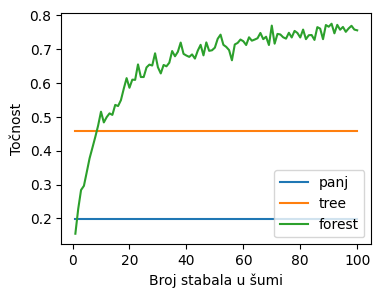

In [50]:
stump = tree.DecisionTreeClassifier(max_depth=1)
dtree = tree.DecisionTreeClassifier(max_depth=3)
rf = ensemble.RandomForestClassifier(max_features=1, max_depth=1)

tree_classifier = {'stump': stump, 'dtree': dtree, 'rf': rf}
max_est = 100
digits_ftrs, digits_tgt = digits.data, digits.target
data = (digits_ftrs, digits_tgt)

stump_score = fit_predict(stump, data)
tree_score = fit_predict(dtree, data)
rf_score = [fit_predict(rf.set_params(n_estimators=n), data) for n in range(1, max_est+1)]


fig, ax = plt.subplots(figsize=(4,3))

xs = list(range(1,max_est+1))
ax.plot(xs, np.repeat(stump_score, max_est), label='panj')
ax.plot(xs, np.repeat(tree_score, max_est),  label='tree')
ax.plot(xs, rf_score, label='forest')

ax.set_xlabel('Broj stabala u šumi')
ax.set_ylabel('Točnost')
ax.legend(loc='lower right');

GradientBoosting: max acc = 0.9778 @ n_estimators = 1
AdaBoost        : max acc = 0.9556 @ n_estimators = 7


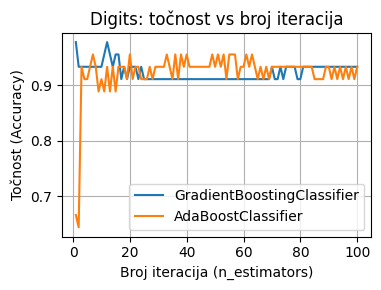

In [52]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)

gb.fit(X_train, y_train)
ada.fit(X_train, y_train)

acc_gb = [accuracy_score(y_test, y_pred) for y_pred in gb.staged_predict(X_test)]
acc_ada = [accuracy_score(y_test, y_pred) for y_pred in ada.staged_predict(X_test)]
iters = np.arange(1, 101)
best_gb_idx = int(np.argmax(acc_gb))
best_ada_idx = int(np.argmax(acc_ada))
print(f"GradientBoosting: max acc = {acc_gb[best_gb_idx]:.4f} @ n_estimators = {best_gb_idx+1}")
print(f"AdaBoost        : max acc = {acc_ada[best_ada_idx]:.4f} @ n_estimators = {best_ada_idx+1}")
plt.figure(figsize=(4,3))
plt.plot(iters, acc_gb, label="GradientBoostingClassifier")
plt.plot(iters, acc_ada, label="AdaBoostClassifier")
plt.xlabel("Broj iteracija (n_estimators)")
plt.ylabel("Točnost (Accuracy)")
plt.title("Digits: točnost vs broj iteracija")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()